# GPU scattering, DFT convergence and complex far field
Requires the built native CUDA extension and an NVIDIA GPU. Run all cells with the project `.venv` kernel.
The example uses a PEC cylinder so an independent analytical solution is available.
FDTD, equivalent-current DFTs, device stopping and NF2FF remain on the GPU. Plotting uses only final far fields and small diagnostics.

The quantity often called “RCS” in a scattering plot is **2D scattering width** here, in metres.
This z-invariant TMz solver does not return 3D RCS in square metres or dBsm.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/fdtdmesh").is_dir())
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from fdtdmesh.cases import canonical_case
from fdtdmesh.constants import C0
from fdtdmesh.simulation import Convergence, run_scattering

OUT = ROOT / "artifacts/notebooks"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

In [3]:
from dataclasses import replace

from fdtdmesh.scattering import cylinder_amplitude, pattern_error
from fdtdmesh.solver.tmz import cuda_backend

cuda_backend()  # Fail clearly if this kernel cannot load the CUDA extension.
FREQUENCIES = (0.9e9, 1.0e9, 1.1e9)
policy = Convergence(check_interval=256, stable_checks=3, rtol=1e-5)
case, mesh = canonical_case("cylinder", ppw=24, frequencies=FREQUENCIES, convergence=policy)
lam0 = C0 / case.frequency
reports = []


def progress(report):
    reports.append(report)
    print(
        f"step {report['step']}: worst-bin ratio {report['dft_error_ratio']:.3g}; stable {report['stable_checks']}"
    )


result = run_scattering(case, mesh, progress=progress)
assert result.converged and result.debug == {}
print({k: result.diagnostics[k] for k in ["Nt", "gpu_ms", "result_d2h_bytes", "debug_d2h_bytes"]})
result.save(OUT / "cylinder_multibin.npz")

step 1792: worst-bin ratio 2.69e-05; stable 3
{'Nt': 1792, 'gpu_ms': 46.23052978515625, 'result_d2h_bytes': 25920, 'debug_d2h_bytes': 0}


## Convergence of the simultaneous multi-bin run
`history[:,2]` is the worst ratio over all requested bins, including incident-spectrum settling.
It is not an individual-bin trace and is not a far-field accuracy estimate. The GPU requires this ratio below one,
residual field below its tolerance, the source/propagation guard, and consecutive successful checks.
Checkpoint spacing is 256 here for a detailed plot; production default is 2048.
Callbacks may skip intermediate reports; the final history contains every checkpoint.

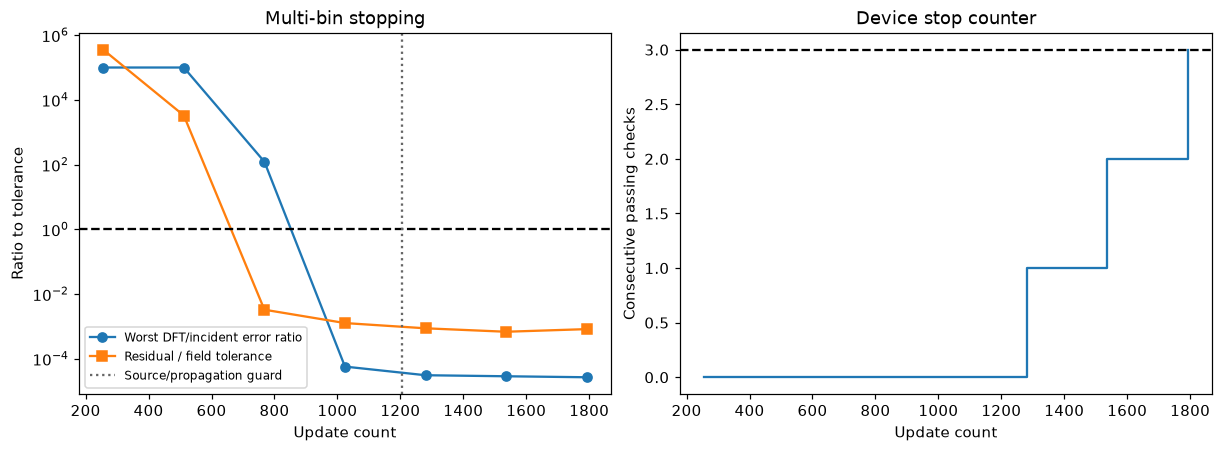

In [4]:
h = result.history
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].semilogy(h[:, 0], np.maximum(h[:, 2], 1e-16), "o-", label="Worst DFT/incident error ratio")
axes[0].semilogy(
    h[:, 0], np.maximum(h[:, 3] / policy.field_tol, 1e-16), "s-", label="Residual / field tolerance"
)
axes[0].axhline(1, color="black", ls="--")
axes[0].axvline(
    result.diagnostics["configuration"]["minimum_steps"],
    color=".4",
    ls=":",
    label="Source/propagation guard",
)
axes[0].set(xlabel="Update count", ylabel="Ratio to tolerance", title="Multi-bin stopping")
axes[0].legend(fontsize=8)
axes[1].step(h[:, 0], h[:, 4], where="post")
axes[1].axhline(policy.stable_checks, color="black", ls="--")
axes[1].set(xlabel="Update count", ylabel="Consecutive passing checks", title="Device stop counter")
fig.savefig(OUT / "dft_convergence.png", dpi=160)
plt.show()

## Inspect each frequency's settling separately
The current API stores only the worst-bin trace for a multi-bin run. To visualize each frequency without downloading currents,
we repeat the same source/mesh simulation with one monitored frequency at a time. These are **separate runs**, each with its own stop time;
they are not hidden per-bin history from the previous run. Each trace still includes that bin's incident-normalization test.

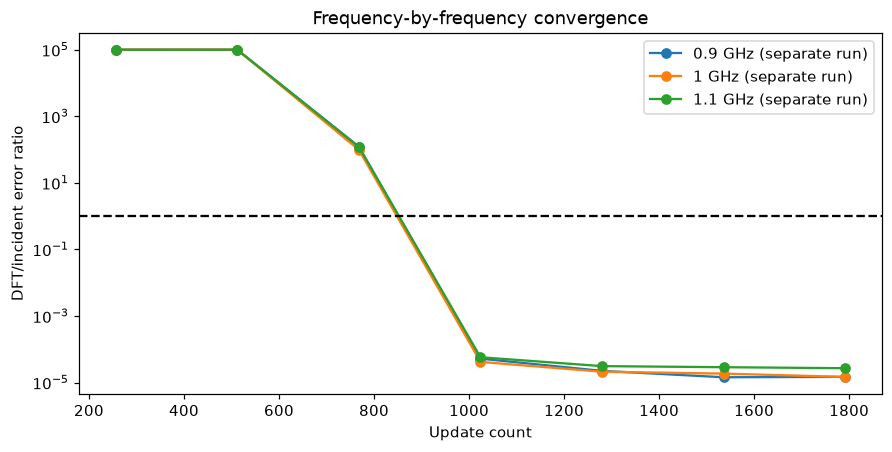

In [5]:
single_bin_results = [run_scattering(replace(case, frequencies=(f,)), mesh) for f in FREQUENCIES]
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for f, r in zip(FREQUENCIES, single_bin_results):
    ax.semilogy(
        r.history[:, 0],
        np.maximum(r.history[:, 2], 1e-16),
        "o-",
        label=f"{f / 1e9:g} GHz (separate run)",
    )
ax.axhline(1, color="black", ls="--")
ax.set(
    xlabel="Update count",
    ylabel="DFT/incident error ratio",
    title="Frequency-by-frequency convergence",
)
ax.legend()
plt.show()

## Absolute scattering width (“2D RCS”)
`result.width[f, angle]` is σ₂D in metres. We plot σ₂D/λ and 10 log10(σ₂D/λ);
the latter is a dimensionless dB ratio, not dBsm. Zero degrees is forward (+x), 180 degrees is backscatter.
The cylinder radius stays fixed across all frequency bins.

0.9 GHz width relative L2 error: 0.630%
1 GHz width relative L2 error: 0.975%
1.1 GHz width relative L2 error: 0.768%


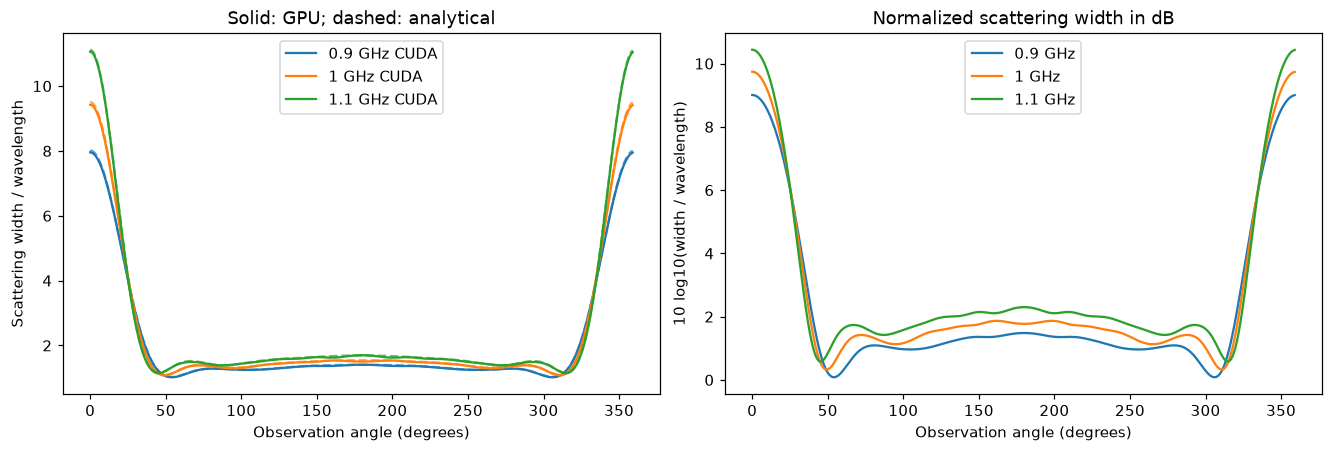

In [6]:
theta = np.rad2deg(result.angles)
radius = 0.47 * lam0
exact = np.array([cylinder_amplitude(radius, f, result.angles) for f in result.frequencies])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for i, f in enumerate(result.frequencies):
    wavelength = C0 / f
    normalized = result.width[i] / wavelength
    axes[0].plot(theta, normalized, label=f"{f / 1e9:g} GHz CUDA")
    axes[0].plot(
        theta,
        4 / (2 * np.pi) * abs(exact[i]) ** 2,
        "--",
        color=axes[0].lines[-1].get_color(),
        alpha=0.7,
    )
    axes[1].plot(theta, 10 * np.log10(np.maximum(normalized, 1e-15)), label=f"{f / 1e9:g} GHz")
    print(
        f"{f / 1e9:g} GHz width relative L2 error: {pattern_error(result.width[i], 4 / (2 * np.pi * f / C0) * abs(exact[i]) ** 2):.3%}"
    )
axes[0].set(
    xlabel="Observation angle (degrees)",
    ylabel="Scattering width / wavelength",
    title="Solid: GPU; dashed: analytical",
)
axes[1].set(
    xlabel="Observation angle (degrees)",
    ylabel="10 log10(width / wavelength)",
    title="Normalized scattering width in dB",
)
for ax in axes:
    ax.legend()
fig.savefig(OUT / "scattering_width.png", dpi=160)
plt.show()

## Complex far-field amplitude and phase
`amplitude` is the dimensionless complex S with σ₂D = 4|S|²/k, normalized by the incident DFT at `case.origin`.
The phasor convention is exp(+iωt); outgoing waves use Hankel kind 2. Changing the phase origin changes complex phase.
Phase is masked near amplitude nulls because its interpretation there is unstable.

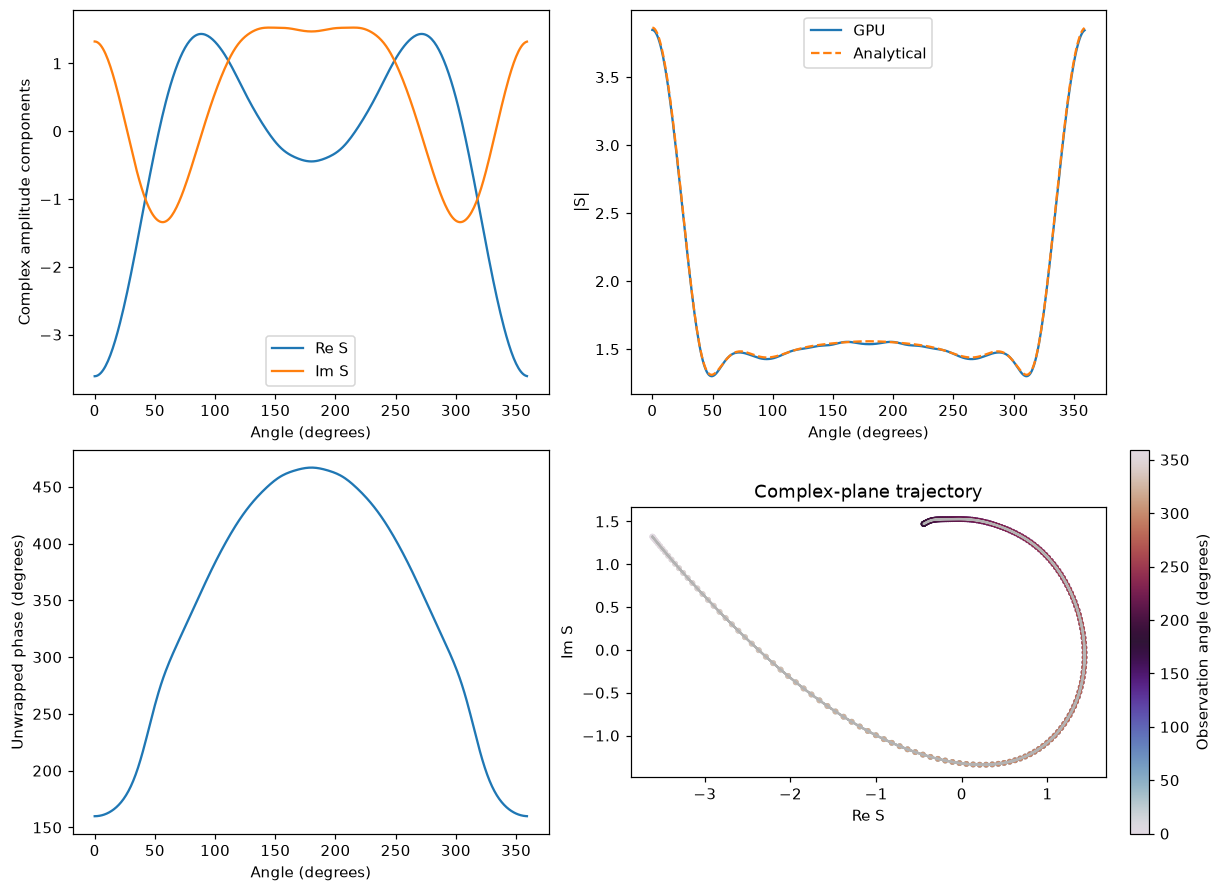

In [7]:
i = int(np.argmin(abs(result.frequencies - case.frequency)))
S = result.amplitude[i]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for values, label in [(S.real, "Re S"), (S.imag, "Im S")]:
    axes[0, 0].plot(theta, values, label=label)
axes[0, 0].set(ylabel="Complex amplitude components", xlabel="Angle (degrees)")
axes[0, 0].legend()
axes[0, 1].plot(theta, abs(S), label="GPU")
axes[0, 1].plot(theta, abs(exact[i]), "--", label="Analytical")
axes[0, 1].set(xlabel="Angle (degrees)", ylabel="|S|")
axes[0, 1].legend()
phase = np.rad2deg(np.unwrap(np.angle(S)))
phase[abs(S) < 1e-3 * abs(S).max()] = np.nan
axes[1, 0].plot(theta, phase)
axes[1, 0].set(xlabel="Angle (degrees)", ylabel="Unwrapped phase (degrees)")
axes[1, 1].plot(S.real, S.imag, color=".7")
points = axes[1, 1].scatter(S.real, S.imag, c=theta, cmap="twilight", s=8)
fig.colorbar(points, ax=axes[1, 1], label="Observation angle (degrees)")
axes[1, 1].set(xlabel="Re S", ylabel="Im S", aspect="equal", title="Complex-plane trajectory")
fig.savefig(OUT / "complex_far_field.png", dpi=160)
plt.show()

## Save and reopen results without a GPU
The saved archive includes final patterns, mesh lines, convergence history and JSON diagnostics.
No live CUDA context is required to load or plot it. A `ScatteringResult.load` method is not currently provided.

In [8]:
import json

with np.load(OUT / "cylinder_multibin.npz", allow_pickle=False) as saved:
    saved_amplitude = saved["amplitude"].copy()
    diagnostics = json.loads(str(saved["diagnostics"]))
np.testing.assert_array_equal(saved_amplitude, result.amplitude)
assert diagnostics["status"] == "converged"
print("Round-trip verified; files are under artifacts/notebooks/")

Round-trip verified; files are under artifacts/notebooks/


For non-circular objects remove the analytical-cylinder comparison, or use a separately qualified reference.
A small convergence ratio means the transient calculation has settled; it does not measure mesh error.
Repeat at finer spatial resolution and check contour/PML sensitivity before generating training references.